In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [3]:
X = 6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1)
# y = 0.8^2 + 0.9x + 2

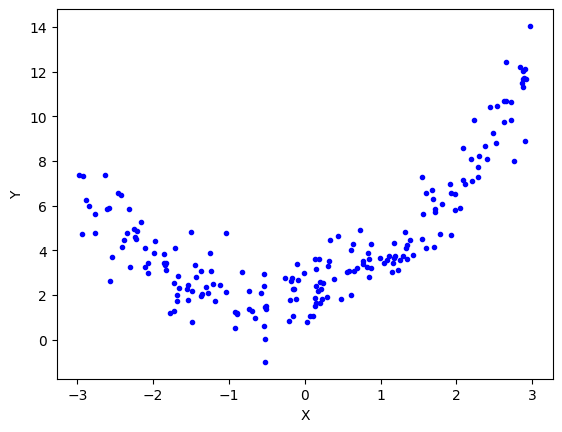

In [4]:
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [5]:
# Train test splot
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [6]:
# Apply Linear Regression 
lr = LinearRegression()

In [7]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred = lr.predict(X_test)

In [9]:
r2_score(y_test,y_pred)

0.12743370971123236

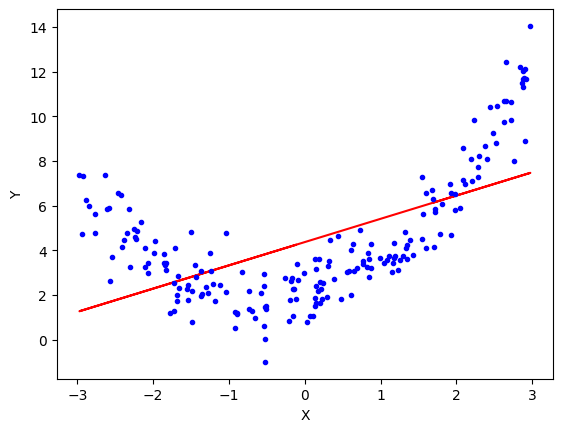

In [10]:
plt.plot(X_train,lr.predict(X_train),color = "r")
plt.plot(X,y,"b.")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [15]:
# Apply the Polynomial Linear Regression 
# degree 2
poly = PolynomialFeatures(degree=2,include_bias=True)
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [16]:
print(X_train[0])
print(X_train_trans[0])

[-0.11990837]
[ 1.         -0.11990837  0.01437802]


In [17]:
# include_bias parameter
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_pred = lr.predict(X_test_trans)

In [19]:
r2_score(y_test,y_pred)

0.8608473611866154

In [20]:
print("coeff :",lr.coef_)
print("Intercept : ",lr.intercept_)

coeff : [[0.         0.8125224  0.82964466]]
Intercept :  [2.03821475]


In [21]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

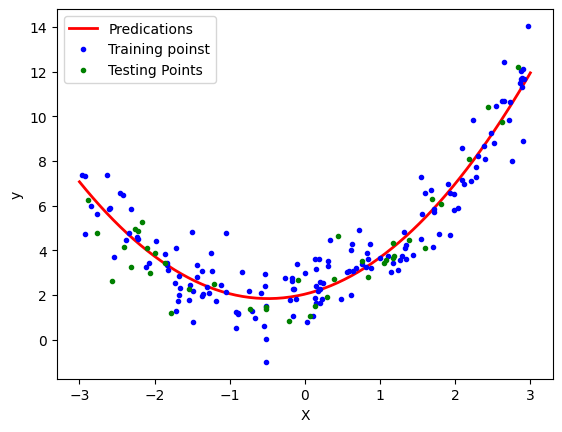

In [22]:
plt.plot(X_new,y_new, "r-",linewidth = 2, label = "Predications")
plt.plot(X_train,y_train,"b.",label="Training poinst")
plt.plot(X_test,y_test,"g.",label="Testing Points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
# Apply Gradient Descent


# Polynomial Regression (Degree = 2) using SGD (Gradient Descent)

In [24]:
# ===============================
# 2. Load Dataset
from sklearn.datasets import load_diabetes
# ===============================
X, y = load_diabetes(return_X_y=True)

# Use only ONE feature for visualization (e.g. BMI column)
X = X[:, 2].reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (442, 1)
y shape: (442,)


In [27]:
# ===============================
# 3. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (353, 1)
X_test: (89, 1)


In [28]:
# ===============================
# 4. Polynomial Feature Transformation
# ===============================
poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

print("After polynomial transform:")
print("X_train_trans:", X_train_trans.shape)


After polynomial transform:
X_train_trans: (353, 3)


In [ ]:
[1, x, x²]

In [29]:
# ===============================
# 5. Gradient Descent Model (SGD)
# ===============================
sgd = SGDRegressor(
    max_iter=1000,
    learning_rate="constant",
    eta0=0.01,
    random_state=42
)

sgd.fit(X_train_trans, y_train)


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [30]:
# ===============================
# 6. Predictions
# ===============================
y_pred = sgd.predict(X_test_trans)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)


R2 Score: 0.22252638093918398


In [31]:
# ===============================
# 7. Create Smooth Curve for Plot
# ===============================
X_new = np.linspace(X.min(), X.max(), 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)

y_new = sgd.predict(X_new_poly)


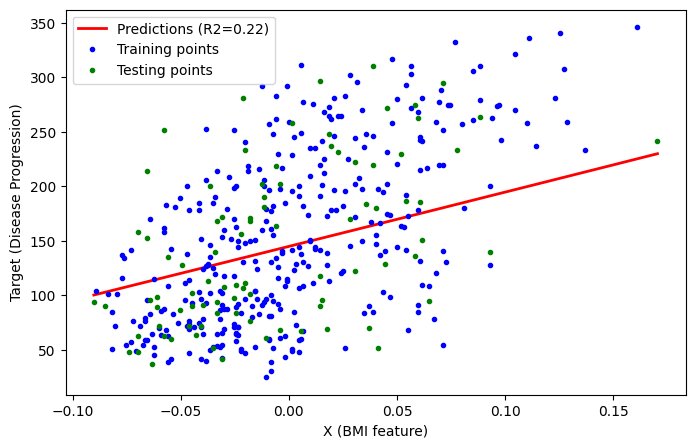

In [32]:
# ===============================
# 8. Plot Results
# ===============================
plt.figure(figsize=(8, 5))

# Prediction curve
plt.plot(
    X_new,
    y_new,
    "r-",
    linewidth=2,
    label=f"Predictions (R2={r2:.2f})"
)

# Training points
plt.plot(X_train, y_train, "b.", label="Training points")

# Testing points
plt.plot(X_test, y_test, "g.", label="Testing points")

plt.xlabel("X (BMI feature)")
plt.ylabel("Target (Disease Progression)")
plt.legend()
plt.show()
